In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Background!
 In the last task we analysed the gas prices over the period of 4 years.
 We Fitted a Linear-Regression model on it and created another year's predected prices.

 Now using that data and the regression model, combining with the other factors involved with storing the Gas over months, we are going to estimate the price of the contract.

** Factors Involved**
1) Injuction dates (Provided by clint).
2) Withdrawal dates (Provided by clint).
3) Price at which the comodity could be purchased/sold (Market rate).
4) Rate at which the gas can be injucted of injercted/withdrawn ($)
5) Maximum Volume that can be stored.
6) Storage Cost

# Fitting Model on Previous Data

In [ ]:
data = pd.read_csv("/content/Nat_GasF.csv")

In [ ]:
X = data.drop(["Prices"],axis=1)
y = data["Prices"]

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
lr = LinearRegression()
lr.fit(X_poly,y)
y_pred = lr.predict(X_poly)

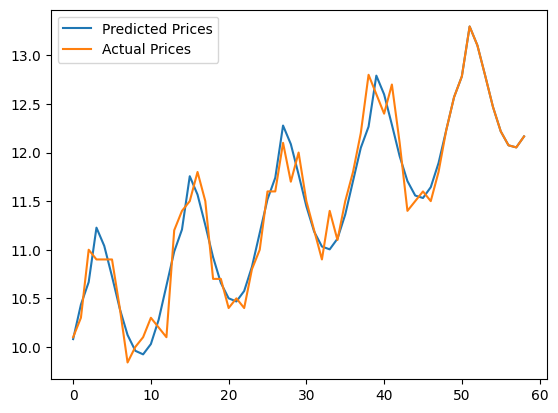

In [ ]:
plt.plot(y_pred,label="Predicted Prices")
plt.plot(y,label="Actual Prices")
plt.legend()

#Function

In [ ]:
def sin_cos(month):
  sin = np.sin(2*np.pi*month/12)
  cos = np.cos(2*np.pi*month/12)
  return [sin, cos]

In [ ]:
def random(ind):
  x = ind[0]
  y = ind[1]
  sin = sin_cos(y)[0]
  cos = sin_cos(y)[1]
  X = np.array([[x,sin,cos]])
  Xp = poly.transform(X)
  yp = lr.predict(Xp)
  return yp

In [ ]:
def value(indate:[], withdate:[], volume, storageC, inoutrate):
  inprice = random(indate)
  withprice = random(withdate)
  value = (inprice-withprice)*volume
  months_kept = ((withdate[0]-indate[0])*12+withdate[1]-indate[1])
  value = value - months_kept*storageC
  value = value-2*inoutrate
  return value

In [ ]:
value([21,1],[21,12],100000,100,50)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([704.74553161])